In [1]:
import os
from google.colab import files

# Uploading kaggle.json
files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('mv kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('kaggle competitions download -c store-sales-time-series-forecasting')
os.system('unzip -q store-sales-time-series-forecasting.zip')

print("Done — files ready")
print(os.listdir('.'))

Saving kaggle.json to kaggle.json
Done — files ready
['.config', 'sample_submission.csv', 'stores.csv', 'holidays_events.csv', 'oil.csv', 'store-sales-time-series-forecasting.zip', 'transactions.csv', 'train.csv', 'test.csv', 'sample_data']


In [2]:
import pandas as pd

train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
transactions = pd.read_csv('transactions.csv')
oil = pd.read_csv('oil.csv')
holidays = pd.read_csv('holidays_events.csv')

print("train:", train.shape)
print("stores:", stores.shape)
print("transactions:", transactions.shape)
print("oil:", oil.shape)
print("holidays:", holidays.shape)

train: (3000888, 6)
stores: (54, 5)
transactions: (83488, 3)
oil: (1218, 2)
holidays: (350, 6)


missing value

In [ ]:
train.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


Merged main data for EDA

In [ ]:

train['date'] = pd.to_datetime(train['date'])
transactions['date'] = pd.to_datetime(transactions['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

# main merge
merged_eda = train.merge(stores, on='store_nbr', how='left')
merged_eda = merged_eda.merge(transactions, on=['store_nbr', 'date'], how='left')
merged_eda = merged_eda.merge(oil, on='date', how='left')
display(merged_eda)
print(merged_eda.shape)
print(merged_eda.columns.tolist())

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13,NaN,NaN
1,1,2013-01-01,1,BABY CARE,0.000,0,Quito,Pichincha,D,13,NaN,NaN
2,2,2013-01-01,1,BEAUTY,0.000,0,Quito,Pichincha,D,13,NaN,NaN
3,3,2013-01-01,1,BEVERAGES,0.000,0,Quito,Pichincha,D,13,NaN,NaN
4,4,2013-01-01,1,BOOKS,0.000,0,Quito,Pichincha,D,13,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,Quito,Pichincha,B,6,2155.0,47.57
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,6,2155.0,47.57
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,Quito,Pichincha,B,6,2155.0,47.57
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,6,2155.0,47.57


(3000888, 12)
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'transactions', 'dcoilwtico']


In [ ]:
print(merged_eda.isnull().sum())

id                   0
date                 0
store_nbr            0
family               0
sales                0
onpromotion          0
city                 0
state                0
type                 0
cluster              0
transactions    245784
dcoilwtico      928422
dtype: int64


## Finding: Missing Oil Prices Follow US Market Calendar

The oil price column (dcoilwtico = West Texas Intermediate crude)
is missing on US public holidays — not Ecuadorian ones.
This is because WTI crude is traded on US commodity exchanges,
which close on US federal holidays.

Missing dates align with: New Year's Day, MLK Day, Presidents Day,
Memorial Day, July 4th, Labor Day, Thanksgiving, Christmas.

Fix: ffill() + bfill() applied to carry last known price forward.

In [ ]:
print("Negative sales rows:", (merged_eda['sales'] < 0).sum())
merged_eda = merged_eda[merged_eda['sales'] >= 0]  # removing negatives
print("Clean dataframe shape:", merged_eda.shape)

#forward filling and backward filling for nulls
merged_eda['dcoilwtico'] = merged_eda['dcoilwtico'].ffill().bfill()
print("Oil NaNs remaining:", merged_eda['dcoilwtico'].isnull().sum())

Negative sales rows: 0
Clean dataframe shape: (3000888, 16)
Oil NaNs remaining: 0


In [ ]:
merged_eda['transactions'] = merged_eda['transactions'].fillna(0)
print("Transaction NaNs:", merged_eda['transactions'].isnull().sum())

Transaction NaNs: 0


In [ ]:
# fining dates where oil is missing (before filling it)

oil_raw = pd.read_csv('oil.csv')
oil_raw['date'] = pd.to_datetime(oil_raw['date'])

# check which days of week are missing
oil_raw['day_of_week'] = oil_raw['date'].dt.day_name()
missing_oil = oil_raw[oil_raw['dcoilwtico'].isna()]
print(missing_oil['day_of_week'].value_counts())

day_of_week
Monday       23
Friday        9
Thursday      7
Tuesday       2
Wednesday     2
Name: count, dtype: int64


In [ ]:
# see all missing oil price rows with full detail
missing_oil = oil_raw[oil_raw['dcoilwtico'].isna()]
print(missing_oil.to_string())

           date  dcoilwtico day_of_week
0    2013-01-01         NaN     Tuesday
14   2013-01-21         NaN      Monday
34   2013-02-18         NaN      Monday
63   2013-03-29         NaN      Friday
104  2013-05-27         NaN      Monday
132  2013-07-04         NaN    Thursday
174  2013-09-02         NaN      Monday
237  2013-11-28         NaN    Thursday
256  2013-12-25         NaN   Wednesday
261  2014-01-01         NaN   Wednesday
274  2014-01-20         NaN      Monday
294  2014-02-17         NaN      Monday
338  2014-04-18         NaN      Friday
364  2014-05-26         NaN      Monday
393  2014-07-04         NaN      Friday
434  2014-09-01         NaN      Monday
497  2014-11-27         NaN    Thursday
517  2014-12-25         NaN    Thursday
522  2015-01-01         NaN    Thursday
534  2015-01-19         NaN      Monday
554  2015-02-16         NaN      Monday
588  2015-04-03         NaN      Friday
624  2015-05-25         NaN      Monday
653  2015-07-03         NaN      Friday


In [ ]:
holidays[
    holidays['date'].isin(lowest_days['date'])
][['date','type','description']]

,date,type,description
41,2013-01-01,Holiday,Primer dia del ano
42,2013-01-05,Work Day,Recupero puente Navidad
43,2013-01-12,Work Day,Recupero puente primer dia del ano
44,2013-02-11,Holiday,Carnaval
45,2013-02-12,Holiday,Carnaval
...,...,...,...
322,2017-07-25,Additional,Fundacion de Guayaquil
323,2017-08-05,Holiday,Fundacion de Esmeraldas
324,2017-08-10,Holiday,Primer Grito de Independencia
325,2017-08-11,Transfer,Traslado Primer Grito de Independencia


## EDA Summary — Key Findings

1. Sales grew consistently from 2013 to 2017 with clear upward trend
2. December is the peak month — Christmas seasonality is strong
3. Weekends (Saturday/Sunday) outsell weekdays by ~35%
4. GROCERY I, BEVERAGES, PRODUCE dominate — top 3 families drive majority of volume
5. Promotions drive ~7x higher average sales than non-promotional days
6. More items on promotion = proportionally higher sales (strong linear relationship)
7. Oil price crash in 2015 did NOT reduce sales — inverse relationship observed
8. Sharp daily dips in sales trend correspond to national/public holidays

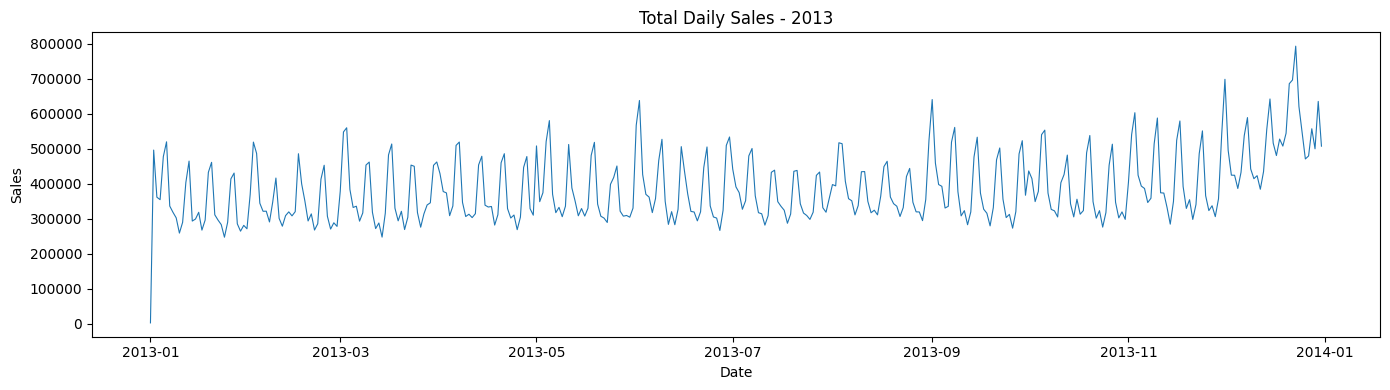

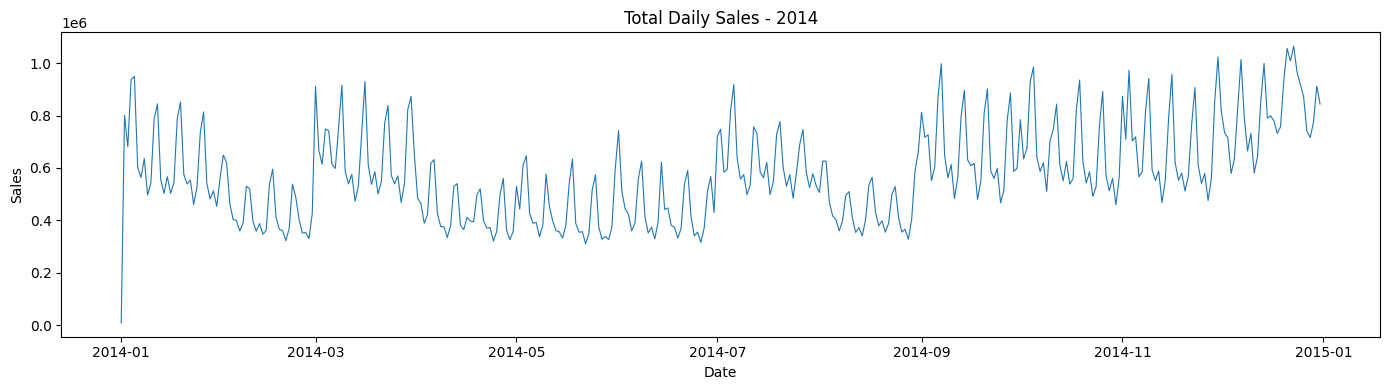

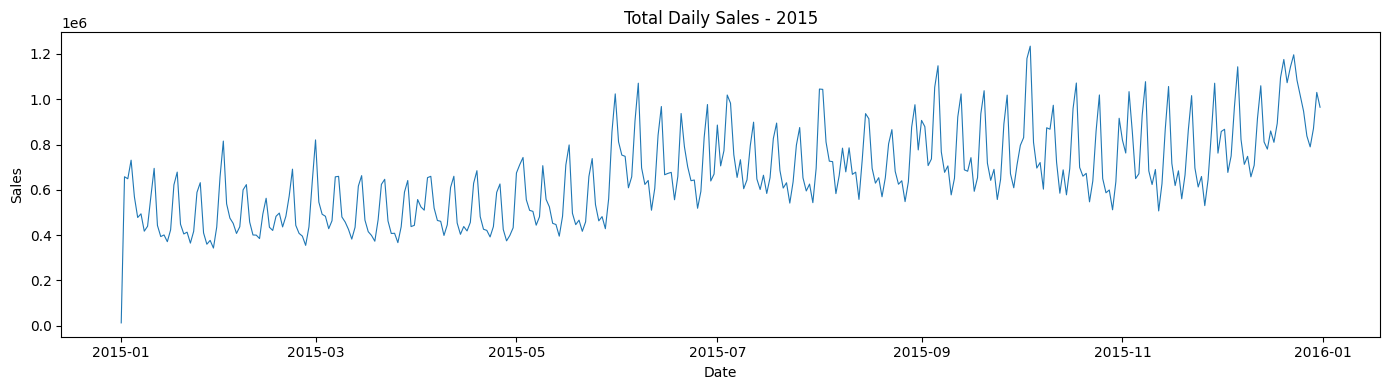

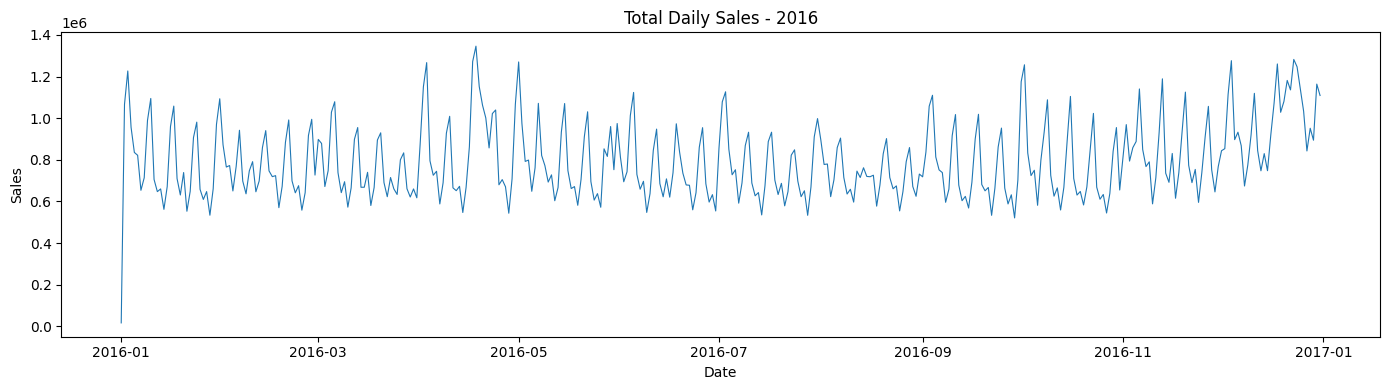

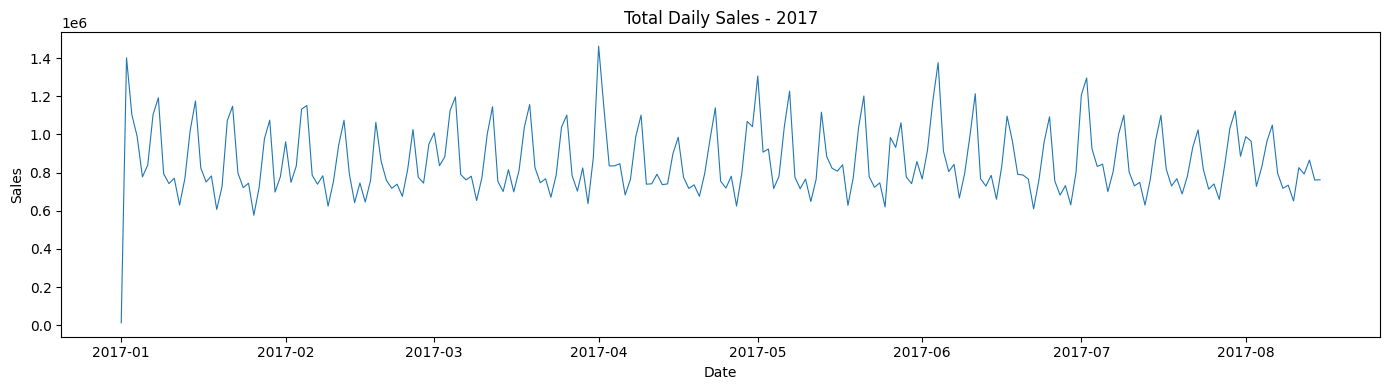

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
daily_sales = merged_eda.groupby('date')['sales'].sum().reset_index()

daily_sales['year'] = daily_sales['date'].dt.year

for year in sorted(daily_sales['year'].unique()):

    temp = daily_sales[daily_sales['year'] == year]

    plt.figure(figsize=(14,4))
    plt.plot(temp['date'], temp['sales'], linewidth=0.8)
    plt.title(f'Total Daily Sales - {year}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.tight_layout()
    plt.show()

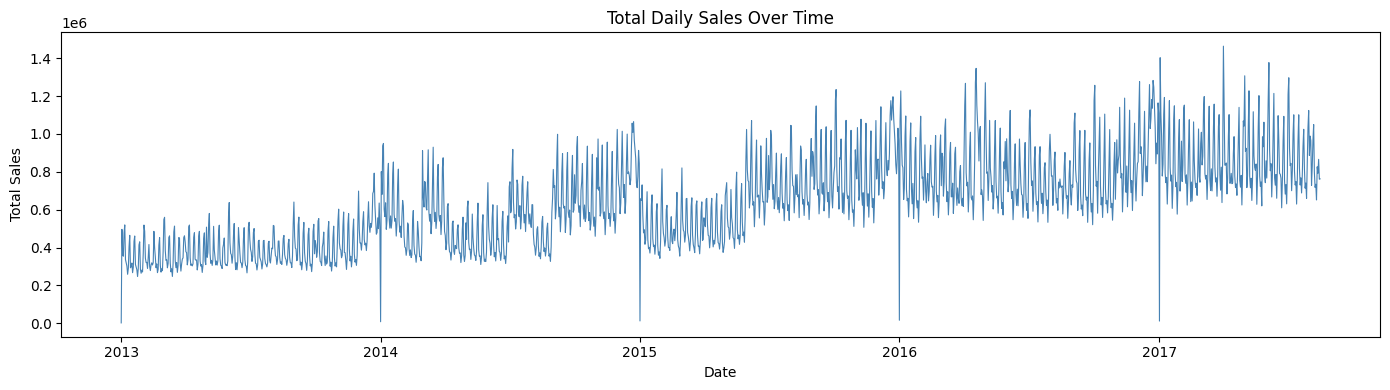

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

daily_sales = merged_eda.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14,4))
plt.plot(daily_sales['date'], daily_sales['sales'], color='steelblue', linewidth=0.8)
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

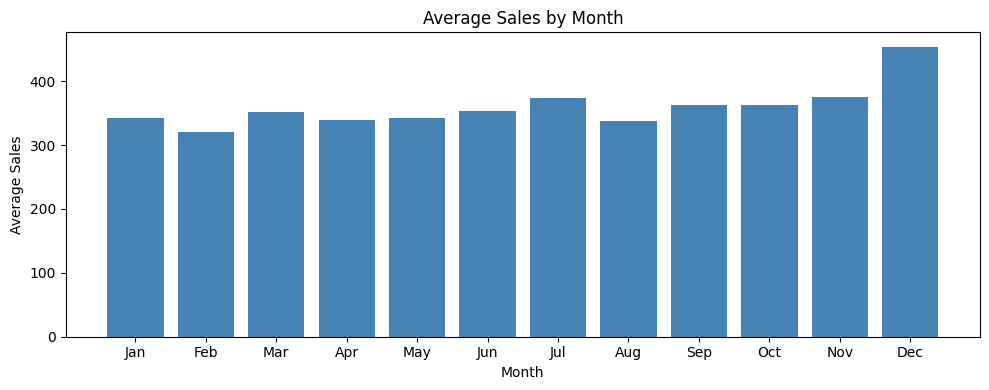

In [ ]:
merged_eda['month'] = merged_eda['date'].dt.month
monthly_sales = merged_eda.groupby('month')['sales'].mean().reset_index()

plt.figure(figsize=(10,4))
plt.bar(monthly_sales['month'], monthly_sales['sales'], color='steelblue')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

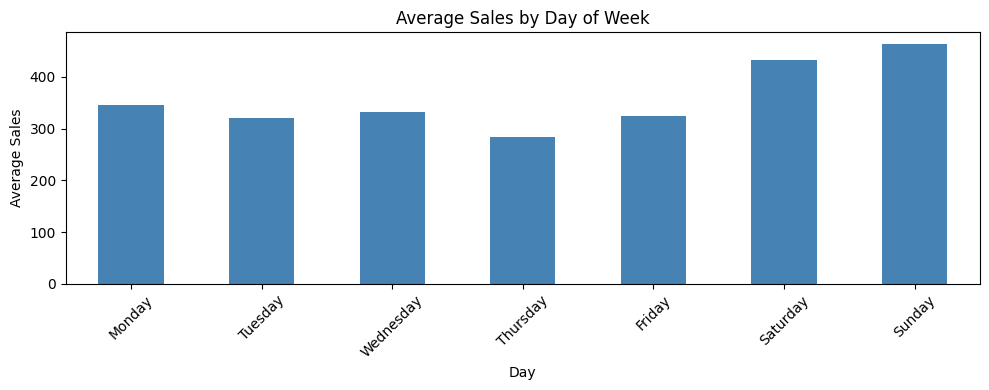

In [ ]:
merged_eda['day_of_week'] = merged_eda['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales = merged_eda.groupby('day_of_week')['sales'].mean().reindex(dow_order)

plt.figure(figsize=(10,4))
dow_sales.plot(kind='bar', color='steelblue')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

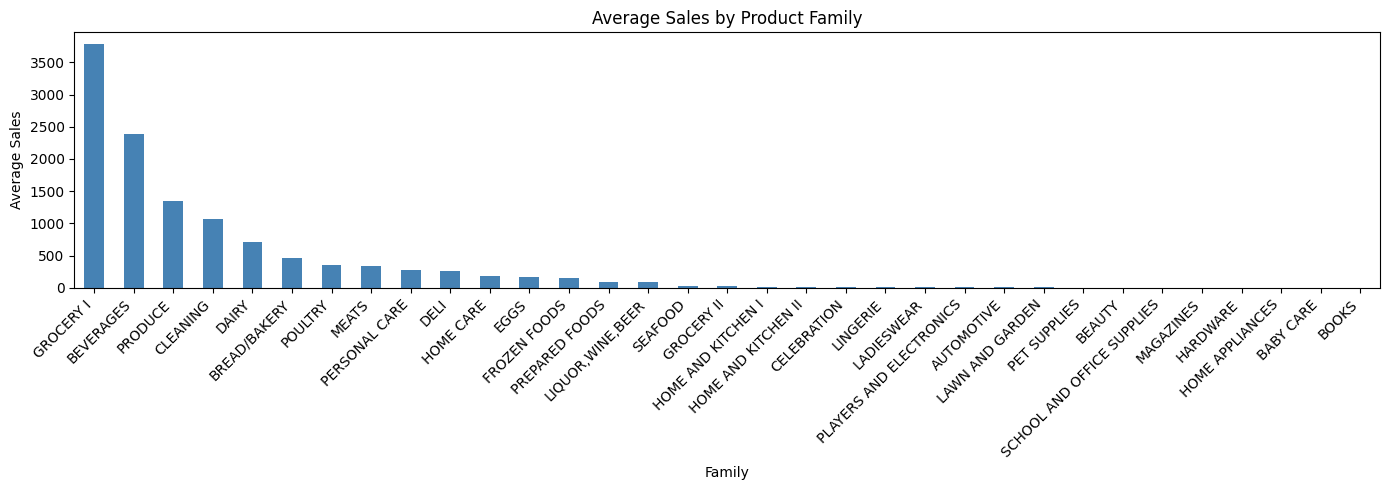

In [ ]:
family_sales = merged_eda.groupby('family')['sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,5))
family_sales.plot(kind='bar', color='steelblue')
plt.title('Average Sales by Product Family')
plt.xlabel('Family')
plt.ylabel('Average Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

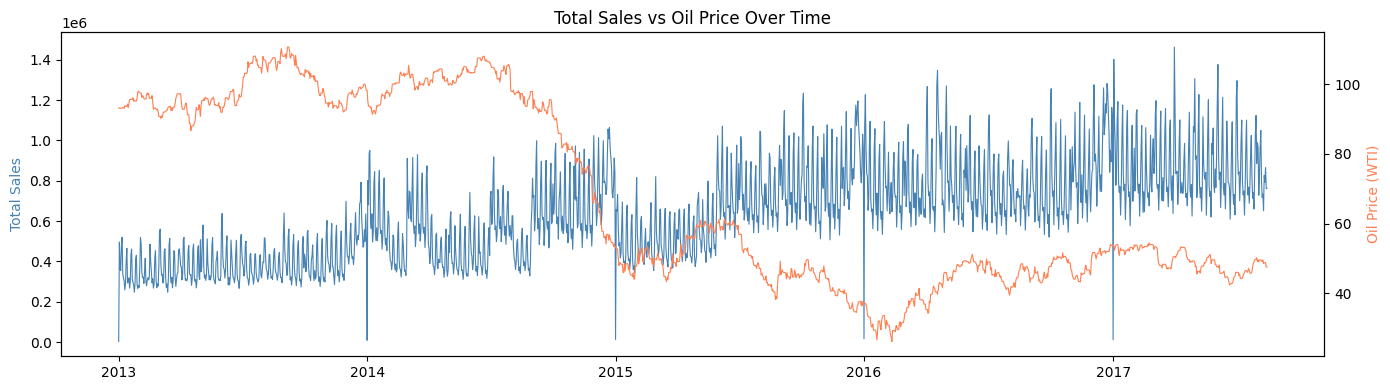

In [ ]:
oil_sales = merged_eda.groupby('date').agg({'sales':'sum', 'dcoilwtico':'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(14,4))
ax1.plot(oil_sales['date'], oil_sales['sales'], color='steelblue', linewidth=0.8, label='Sales')
ax1.set_ylabel('Total Sales', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(oil_sales['date'], oil_sales['dcoilwtico'], color='coral', linewidth=0.8, label='Oil Price')
ax2.set_ylabel('Oil Price (WTI)', color='coral')

plt.title('Total Sales vs Oil Price Over Time')
fig.tight_layout()
plt.show()

In [ ]:
print(merged_eda['onpromotion'].unique()[:20])
print(merged_eda['onpromotion'].nunique())

[ 0  3  5  1 56 20 19  2  4 18 17 12  6  7 10  9 50  8 16 42]
362


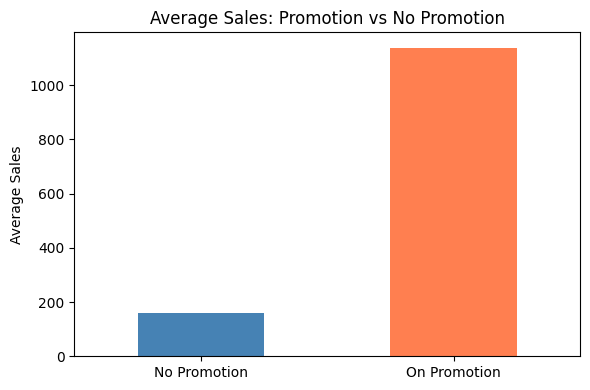

In [ ]:
merged_eda['promo_flag'] = (merged_eda['onpromotion'] > 0).astype(int)

promo_sales = merged_eda.groupby('promo_flag')['sales'].mean()
promo_sales.index = ['No Promotion', 'On Promotion']

plt.figure(figsize=(6,4))
promo_sales.plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Average Sales: Promotion vs No Promotion')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

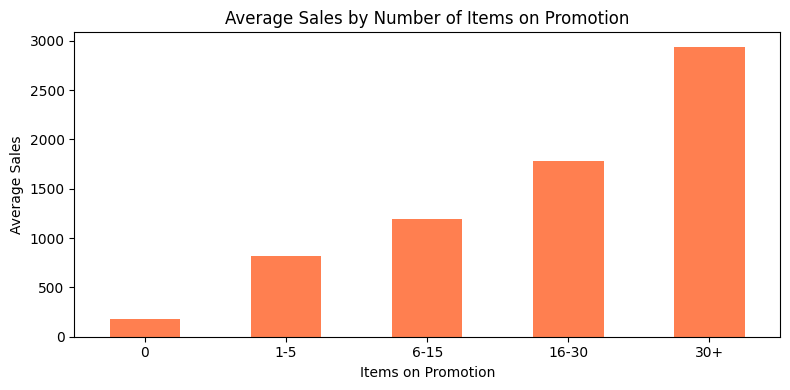

In [ ]:
promo_bins = pd.cut(merged_eda['onpromotion'],
                    bins=[0, 1, 5, 15, 30, 999],
                    labels=['0', '1-5', '6-15', '16-30', '30+'],
                    include_lowest=True)

promo_impact = merged_eda.groupby(promo_bins, observed=True)['sales'].mean()

plt.figure(figsize=(8,4))
promo_impact.plot(kind='bar', color='coral')
plt.title('Average Sales by Number of Items on Promotion')
plt.xlabel('Items on Promotion')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Finding: Oil Price vs Sales — Spurious Correlation

Row-level correlation: -0.07 (near zero — no direct relationship)
Daily aggregate correlation: -0.63 (moderate inverse — appears significant)

The aggregate correlation is likely spurious:
- Both oil price and sales are time-dependent variables
- Oil fell steadily 2013→2017 while sales grew due to store expansion
- Time is the confounding variable driving both trends independently

Average sales grew 57% post oil crash (+276K daily) — but this
growth is better explained by store network expansion and
increased promotional activity than by oil price movements.

Conclusion: Oil price removed as a causal feature. Retained only
as a weak macroeconomic context signal in the model.

In [ ]:
# simple correlation
correlation = merged_eda[['sales', 'dcoilwtico']].corr()
print(correlation)

               sales  dcoilwtico
sales       1.000000   -0.074808
dcoilwtico -0.074808    1.000000


In [ ]:
daily = merged_eda.groupby('date').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean'
}).reset_index()

correlation_daily = daily[['sales', 'dcoilwtico']].corr()
print(correlation_daily)

               sales  dcoilwtico
sales       1.000000   -0.626889
dcoilwtico -0.626889    1.000000


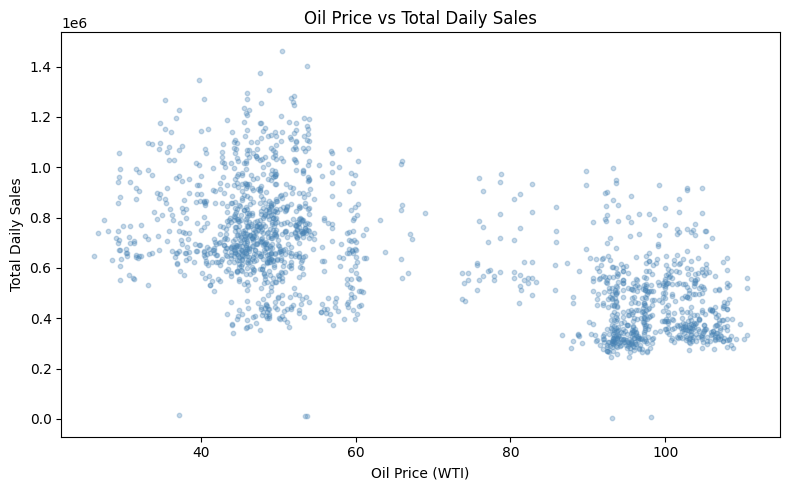

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(daily['dcoilwtico'], daily['sales'], alpha=0.3, color='steelblue', s=10)
plt.title('Oil Price vs Total Daily Sales')
plt.xlabel('Oil Price (WTI)')
plt.ylabel('Total Daily Sales')
plt.tight_layout()
plt.show()

In [ ]:
# before oil crash vs after
before_crash = daily[daily['date'] < '2015-01-01']['sales'].mean()
after_crash = daily[daily['date'] >= '2015-01-01']['sales'].mean()

print(f"Average daily sales BEFORE oil crash (pre-2015): {before_crash:,.0f}")
print(f"Average daily sales AFTER oil crash (2015+): {after_crash:,.0f}")
print(f"Difference: {after_crash - before_crash:,.0f}")

Average daily sales BEFORE oil crash (pre-2015): 480,623
Average daily sales AFTER oil crash (2015+): 757,062
Difference: 276,440


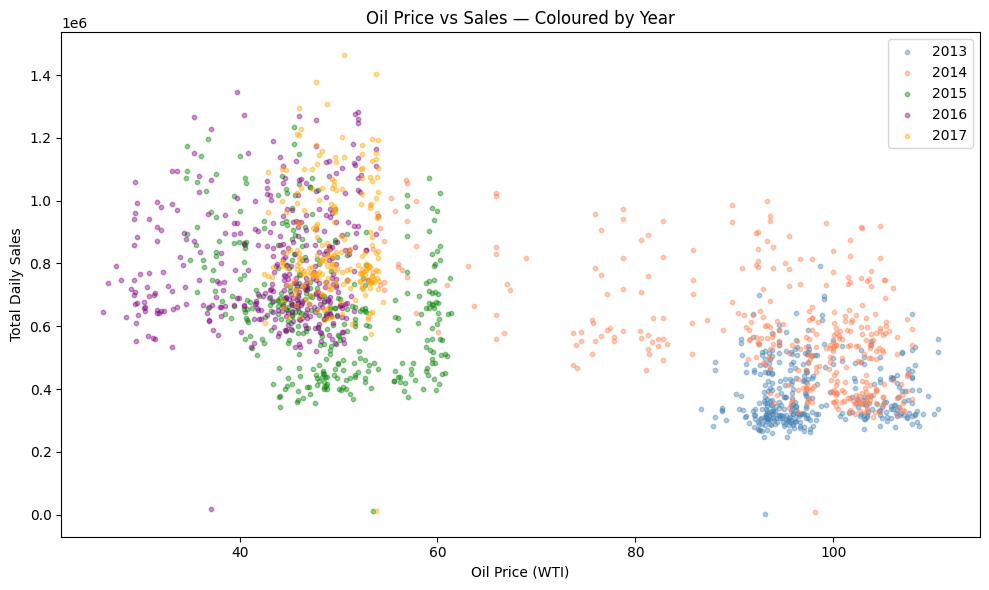

In [ ]:
daily['year'] = daily['date'].dt.year

# plot each year separately with different color
colors = {2013:'steelblue', 2014:'coral', 2015:'green', 2016:'purple', 2017:'orange'}

plt.figure(figsize=(10,6))
for year, group in daily.groupby('year'):
    plt.scatter(group['dcoilwtico'], group['sales'],
                alpha=0.4, s=10, label=str(year), color=colors[year])

plt.title('Oil Price vs Sales — Coloured by Year')
plt.xlabel('Oil Price (WTI)')
plt.ylabel('Total Daily Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
for year, group in daily.groupby('year'):
    corr = group['sales'].corr(group['dcoilwtico'])
    print(f"{year}: correlation = {corr:.3f}")

2013: correlation = 0.040
2014: correlation = -0.527
2015: correlation = -0.323
2016: correlation = 0.113
2017: correlation = 0.012


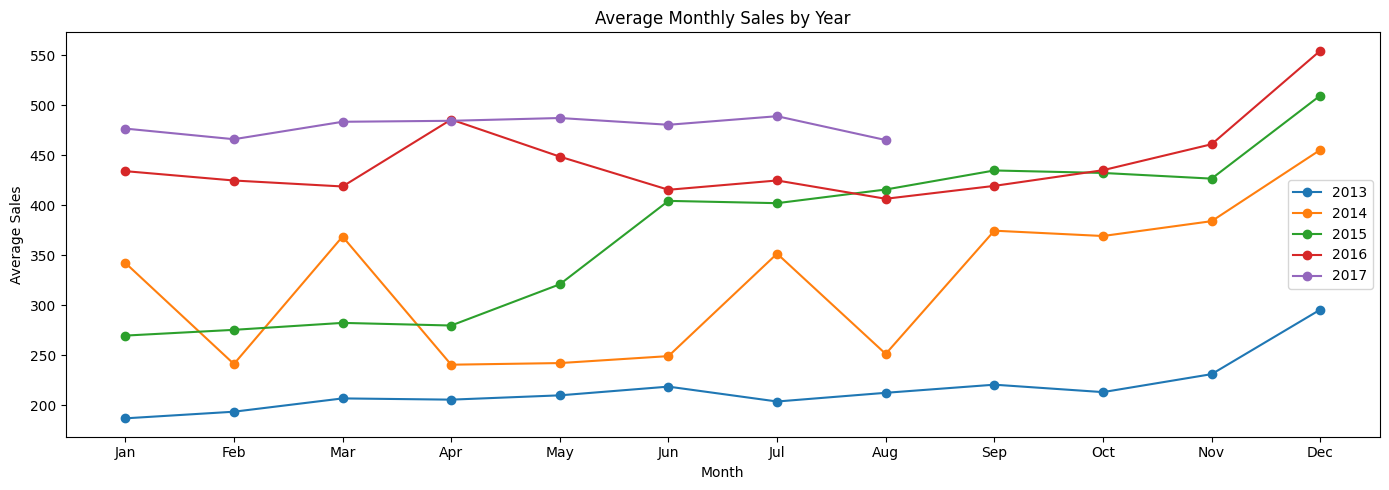

In [ ]:
merged_eda['year'] = merged_eda['date'].dt.year
merged_eda['month'] = merged_eda['date'].dt.month

monthly_yearly = merged_eda.groupby(['year','month'])['sales'].mean().unstack()

plt.figure(figsize=(14,5))
for year in monthly_yearly.index:
    plt.plot(monthly_yearly.columns, monthly_yearly.loc[year], marker='o', label=str(year))

plt.title('Average Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.tight_layout()
plt.show()

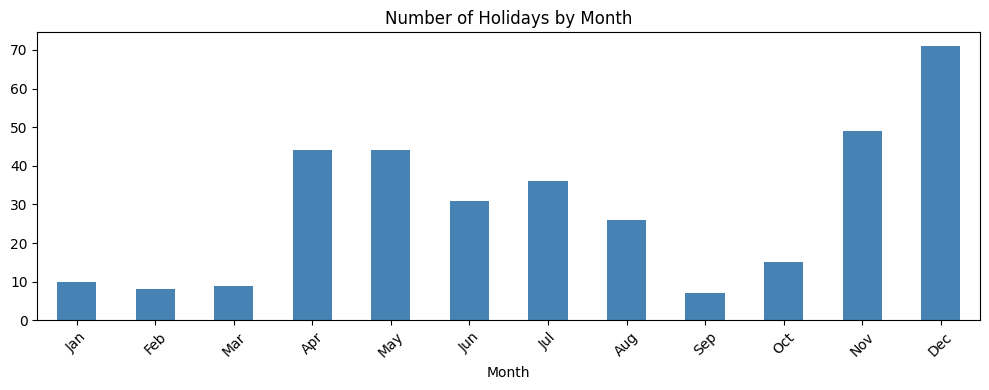

In [ ]:
holidays['date'] = pd.to_datetime(holidays['date'])
holidays['month'] = holidays['date'].dt.month

holiday_count = holidays.groupby('month').size()

plt.figure(figsize=(10,4))
holiday_count.plot(kind='bar', color='steelblue')
plt.title('Number of Holidays by Month')
plt.xlabel('Month')
plt.xticks(range(0,12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.show()

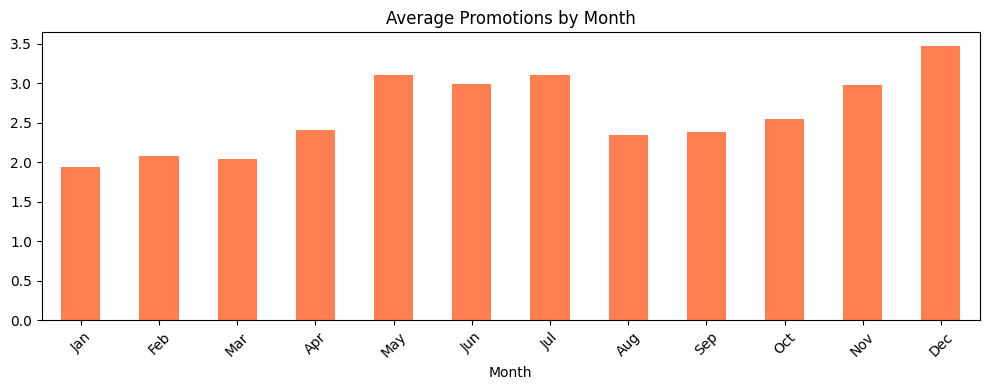

In [ ]:
promo_by_month = merged_eda.groupby('month')['onpromotion'].mean()

plt.figure(figsize=(10,4))
promo_by_month.plot(kind='bar', color='coral')
plt.title('Average Promotions by Month')
plt.xlabel('Month')
plt.xticks(range(0,12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.show()

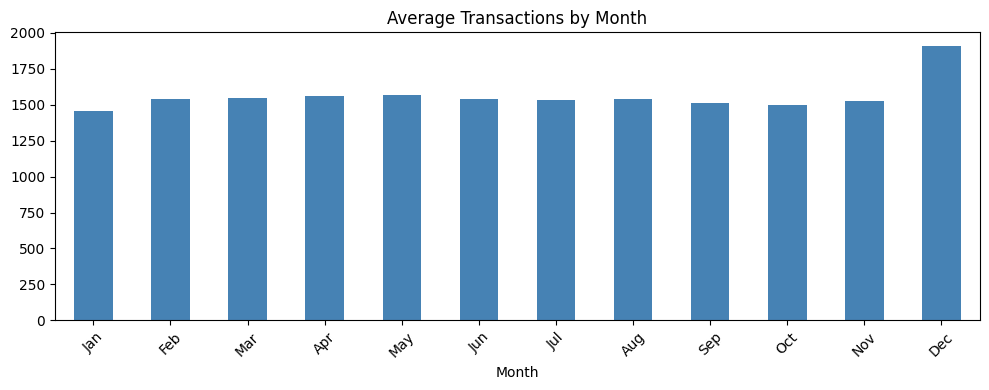

In [ ]:
trans_by_month = merged_eda.groupby('month')['transactions'].mean()

plt.figure(figsize=(10,4))
trans_by_month.plot(kind='bar', color='steelblue')
plt.title('Average Transactions by Month')
plt.xlabel('Month')
plt.xticks(range(0,12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.show()

## Finding: January/February Sales Dip — Root Cause Analysis

The Jan/Feb dip is consistent across all 5 years — structural pattern.

Three contributing factors identified:

1. POST-CHRISTMAS DEMAND HANGOVER
   Transactions lowest in January (~1,450 vs ~1,550 average)
   Consumers recovering from December spending surge

2. PROMOTIONAL WITHDRAWAL
   Lowest average promotions in Jan/Feb/Mar (~2.0 vs 3.0-3.5 rest of year)
   Retailers reset budgets post-Christmas, run fewer campaigns
   Given promotions drive ~7x higher sales, this directly suppresses volume

3. NOT caused by holidays
   Jan/Feb/Mar have fewest holidays (8-10 vs 30-70 rest of year)
   Holiday count actually INVERSELY correlates with the dip

## Spurious Correlation — Final Conclusion
Within-year oil-sales correlations: 0.04, -0.53, -0.32, 0.11, 0.01
Overall -0.63 correlation was entirely time-driven — confirmed spurious
Oil price retained only as weak macro context feature in model